<div align="center" style="font-size: 2.5em; font-weight: bold; margin-bottom: 10px;">ChatGTP</div>
<div align="center" style="font-size: 1.8em; font-weight: bold; margin-bottom: 15px;">Gdje to piše (DzeToPishe)</div>
<div align="center" style="font-size: 1.3em; margin-bottom: 25px;">Diplomski rad - Automatsko ocjenjivanje odgovora</div>
<div align="right" style="font-style: italic; color: #666;">by Zlatko Pračić</div>

## 1. Postavljanje okruženja

Ovaj dio notebooka instalira potrebne biblioteke za izračun metrika i uvozi sve module.

### Instalacija potrebnih biblioteka

Instaliramo biblioteke za automatsko ocjenjivanje:
- **rouge-score** - ROUGE-L metrika za najduži zajednički podniz
- **bert-score** - BERTScore za kontekstualnu semantičku sličnost
- **sentence-transformers** - embedding model za cosine similarity

In [1]:
!pip install rouge-score bert-score
!pip install -U sentence-transformers

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=9d29c3a4de271782c4f06ebbff35e24b34c47ee6d6359cd18b974b642397098d
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


### Uvoz biblioteka

Uvozimo sve potrebne module na jednom mjestu za preglednost.

In [2]:
import pandas as pd
import numpy as np
import json
import logging

from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('Sve biblioteke uspješno učitane.')

Sve biblioteke uspješno učitane.


## 2. Učitavanje podataka

Učitavamo rezultate generiranja iz CSV datoteke i referentne odgovore iz JSON datoteke. CSV sadrži odgovore sva tri pristupa: **Vanilla**, **FAISS RAG** i **GraphRAG**.

### Učitavanje CSV rezultata i JSON referenci

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
csv_path  = '/content/drive/My Drive/diplomskiRad/rezultati.csv'
json_path = '/content/drive/My Drive/diplomskiRad/pitanja_odgovori.json'

df = pd.read_csv(csv_path, encoding='utf-8-sig')

with open(json_path, 'r', encoding='utf-8') as f:
    qa_data = json.load(f)

# Obavezni stupci
potrebni_stupci = ['rbr', 'kategorija', 'pitanje', 'ocekivani_odgovor',
                   'vanilla_odgovor', 'rag_odgovor']
nedostaju = [s for s in potrebni_stupci if s not in df.columns]
if nedostaju:
    raise ValueError(f'Nedostaju stupci u CSV-u: {nedostaju}')

# GraphRAG stupac je opcionalan (može se dodati naknadno)
ima_graph_rag = 'graph_rag_odgovor' in df.columns
if ima_graph_rag:
    print('\u2713 GraphRAG stupac pronađen — evaluacija sva tri pristupa.')
else:
    print('\u26a0  GraphRAG stupac nije pronađen — evaluacija Vanilla i FAISS RAG.')

print(f'\nUčitano {len(df)} redaka iz CSV-a.')
print(f'Stupci: {list(df.columns)}')
print(f'\nKategorije:')
print(df['kategorija'].value_counts().to_string())
print(f'\nJSON metadata: {qa_data["metadata"]["ukupno_pitanja"]} pitanja')

✓ GraphRAG stupac pronađen — evaluacija sva tri pristupa.

Učitano 43 redaka iz CSV-a.
Stupci: ['rbr', 'kategorija', 'pitanje', 'ocekivani_odgovor', 'vanilla_odgovor', 'vanilla_vrijeme_sekunde', 'rag_odgovor', 'rag_vrijeme_sekunde', 'graph_rag_odgovor', 'graph_rag_vrijeme_sekunde']

Kategorije:
kategorija
jednostavna_pitanja                   23
kompleksna_pitanja_vise_dokumenata    12
kompleksna_pitanja_jeden_dokument      8

JSON metadata: 43 pitanja


## 3. Funkcije za izračun metrika

Definiramo 3 metrike za automatsko ocjenjivanje odgovora:
- **ROUGE-L** — leksička metrika, mjeri najduži zajednički podniz (F1)
- **BERTScore** — semantička metrika, kontekstualna sličnost tokena
- **Cosine Similarity** — semantička metrika, sličnost embedding vektora cijelih odgovora

In [5]:
def compute_rouge_l(reference, hypothesis):
    """Izračunava ROUGE-L F1 score između referentnog i generiranog odgovora.

    ROUGE-L mjeri najduži zajednički podniz (Longest Common Subsequence)
    i vraća F1 mjeru koja balansira preciznost i odziv.
    """
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    scores = scorer.score(reference, hypothesis)
    return scores['rougeL'].fmeasure


def compute_bertscore(references, hypotheses):
    """Izračunava BERTScore za liste referenci i hipoteza (batch).

    Koristi bert-base-multilingual-cased koji podržava hrvatski jezik.
    Vraća F1 komponentu BERTScore-a.
    """
    P, R, F1 = bert_score_fn(
        hypotheses, references,
        model_type='bert-base-multilingual-cased',
        num_layers=9,
        verbose=True
    )
    return F1.tolist()


def compute_cosine_similarity(reference, hypothesis, model):
    """Izračunava cosine similarity između embeddinga referentnog i generiranog odgovora.

    Koristi multilingual-e5-large model za vektorizaciju cijelih odgovora.
    """
    emb_ref = model.encode([reference], convert_to_numpy=True)
    emb_hyp = model.encode([hypothesis], convert_to_numpy=True)
    return float(sklearn_cosine(emb_ref, emb_hyp)[0][0])


print('Funkcije za metrike definirane.')

Funkcije za metrike definirane.


## 4. Izračun metrika za sve odgovore

Za svaki od 31 redak računamo 3 metrike za sve prisutne pristupe (Vanilla, FAISS RAG, i GraphRAG ako je dostupan) u usporedbi s očekivanim (referentnim) odgovorom.

### Inicijalizacija embedding modela

In [6]:
_transformers_logger = logging.getLogger('transformers.modeling_utils')
_prev_level = _transformers_logger.level
_transformers_logger.setLevel(logging.ERROR)

embed_model = SentenceTransformer('intfloat/multilingual-e5-large')

_transformers_logger.setLevel(_prev_level)
print('Embedding model učitan.')

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Embedding model učitan.


### Izračun ROUGE-L i Cosine Similarity

In [7]:
vanilla_rouge_l = []
vanilla_cosine  = []
rag_rouge_l     = []
rag_cosine      = []
graph_rouge_l   = []
graph_cosine    = []

for i, row in df.iterrows():
    ref = str(row['ocekivani_odgovor'])
    van = str(row['vanilla_odgovor'])
    rag = str(row['rag_odgovor'])

    vanilla_rouge_l.append(compute_rouge_l(ref, van))
    vanilla_cosine.append(compute_cosine_similarity(ref, van, embed_model))
    rag_rouge_l.append(compute_rouge_l(ref, rag))
    rag_cosine.append(compute_cosine_similarity(ref, rag, embed_model))

    if ima_graph_rag:
        grph = str(row['graph_rag_odgovor'])
        graph_rouge_l.append(compute_rouge_l(ref, grph))
        graph_cosine.append(compute_cosine_similarity(ref, grph, embed_model))

    if (i + 1) % 10 == 0 or i == 0:
        print(f'Obrađeno {i + 1}/{len(df)} pitanja...')

df['vanilla_rouge_l'] = vanilla_rouge_l
df['vanilla_cosine']  = vanilla_cosine
df['rag_rouge_l']     = rag_rouge_l
df['rag_cosine']      = rag_cosine
if ima_graph_rag:
    df['graph_rouge_l'] = graph_rouge_l
    df['graph_cosine']  = graph_cosine

print(f'\nROUGE-L i Cosine Similarity izračunati za svih {len(df)} pitanja.')

Obrađeno 1/43 pitanja...
Obrađeno 10/43 pitanja...
Obrađeno 20/43 pitanja...
Obrađeno 30/43 pitanja...
Obrađeno 40/43 pitanja...

ROUGE-L i Cosine Similarity izračunati za svih 43 pitanja.


### Izračun BERTScore (batch)

In [8]:
references         = df['ocekivani_odgovor'].astype(str).tolist()
vanilla_hypotheses = df['vanilla_odgovor'].astype(str).tolist()
rag_hypotheses     = df['rag_odgovor'].astype(str).tolist()

print('Izračunavam BERTScore za vanilla odgovore...')
df['vanilla_bertscore'] = compute_bertscore(references, vanilla_hypotheses)

print('\nIzračunavam BERTScore za FAISS RAG odgovore...')
df['rag_bertscore'] = compute_bertscore(references, rag_hypotheses)

if ima_graph_rag:
    graph_hypotheses = df['graph_rag_odgovor'].astype(str).tolist()
    print('\nIzračunavam BERTScore za GraphRAG odgovore...')
    df['graph_bertscore'] = compute_bertscore(references, graph_hypotheses)

print(f'\nBERTScore izračunat za svih {len(df)} pitanja.')

Izračunavam BERTScore za vanilla odgovore...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.78 seconds, 55.23 sentences/sec

BERTScore izračunat za svih 43 pitanja.


### Spremanje proširenog CSV-a

In [9]:
output_csv = '/content/drive/My Drive/diplomskiRad/rezultati_evaluacija.csv'
df.to_csv(output_csv, index=False, encoding='utf-8-sig')

print(f'Rezultati spremljeni u: {output_csv}')
print(f'Oblik: {df.shape[0]} redaka × {df.shape[1]} stupaca')
print(f'\nStupci: {list(df.columns)}')

# Pregled prvih redaka s metrikama
pregled_stupci = ['rbr', 'kategorija',
                  'vanilla_rouge_l', 'vanilla_bertscore', 'vanilla_cosine',
                  'rag_rouge_l',     'rag_bertscore',     'rag_cosine']
if ima_graph_rag:
    pregled_stupci += ['graph_rouge_l', 'graph_bertscore', 'graph_cosine']
df[pregled_stupci].head()

Rezultati spremljeni u: /content/drive/My Drive/diplomskiRad/rezultati_evaluacija.csv
Oblik: 43 redaka × 19 stupaca

Stupci: ['rbr', 'kategorija', 'pitanje', 'ocekivani_odgovor', 'vanilla_odgovor', 'vanilla_vrijeme_sekunde', 'rag_odgovor', 'rag_vrijeme_sekunde', 'graph_rag_odgovor', 'graph_rag_vrijeme_sekunde', 'vanilla_rouge_l', 'vanilla_cosine', 'rag_rouge_l', 'rag_cosine', 'graph_rouge_l', 'graph_cosine', 'vanilla_bertscore', 'rag_bertscore', 'graph_bertscore']


,rbr,kategorija,vanilla_rouge_l,vanilla_bertscore,vanilla_cosine,rag_rouge_l,rag_bertscore,rag_cosine,graph_rouge_l,graph_bertscore,graph_cosine
0,1,kompleksna_pitanja_vise_dokumenata,0.117073,0.645665,0.876294,0.084567,0.637021,0.870136,0.090909,0.640205,0.873632
1,2,kompleksna_pitanja_vise_dokumenata,0.158845,0.683119,0.907229,0.176656,0.679140,0.919782,0.179775,0.674234,0.909993
2,3,kompleksna_pitanja_vise_dokumenata,0.194175,0.681242,0.904260,0.165138,0.679958,0.901488,0.214876,0.672208,0.896626
3,4,kompleksna_pitanja_vise_dokumenata,0.077419,0.622562,0.863163,0.141361,0.639493,0.902169,0.130435,0.637197,0.893645
4,5,kompleksna_pitanja_vise_dokumenata,0.095588,0.672423,0.912453,0.146341,0.735597,0.918149,0.111765,0.696601,0.891260


## 5. Agregacija po kategorijama

Grupiramo rezultate po 3 kategorije pitanja i računamo prosječne vrijednosti svih metrika za svaki od pristupa.

### Prosječne metrike po kategorijama

In [10]:
metrike_baze = ['rouge_l', 'bertscore', 'cosine']
metrike_nazivi_kratki = {'rouge_l': 'ROUGE-L', 'bertscore': 'BERTScore', 'cosine': 'Cosine Sim.'}

pristupi = [('vanilla', 'Vanilla'), ('rag', 'FAISS RAG')]
if ima_graph_rag:
    pristupi.append(('graph', 'GraphRAG'))

metrike = [f'{p}_{b}' for p, _ in pristupi for b in metrike_baze]

# Ljepša imena kategorija za prikaz
def naziv_kategorije(k):
    k = k.lower()
    if 'vise' in k or 'više' in k:
        return 'Kompleksna (više dok.)'
    if 'jedan' in k or 'jeden' in k:
        return 'Kompleksna (jedan dok.)'
    return 'Jednostavna'

df_grouped_mean = df.groupby('kategorija')[metrike].mean()
df_grouped_std  = df.groupby('kategorija')[metrike].std()
ukupno_mean = df[metrike].mean()
ukupno_std  = df[metrike].std()

col_header = ''.join(f'{lbl:>18}' for _, lbl in pristupi)
print('=' * (22 + 18 * len(pristupi)))
print('PROSJEČNE METRIKE PO KATEGORIJAMA (mean ± std)')
print('=' * (22 + 18 * len(pristupi)))

for kat in df_grouped_mean.index:
    naziv = naziv_kategorije(kat)
    n = len(df[df['kategorija'] == kat])
    print(f'\n\u25b6 {naziv} (n={n})')
    print('-' * (22 + 18 * len(pristupi)))
    print(f'{"Metrika":<22}{col_header}')
    print('-' * (22 + 18 * len(pristupi)))
    for base in metrike_baze:
        label = metrike_nazivi_kratki[base]
        vals = []
        for p, _ in pristupi:
            col = f'{p}_{base}'
            m = df_grouped_mean.loc[kat, col]
            s = df_grouped_std.loc[kat, col]
            vals.append(f'{m:>6.4f}\u00b1{s:.4f}')
        print(f'{label:<22}{"".join(f"{v:>18}" for v in vals)}')

print(f'\n{"=" * (22 + 18 * len(pristupi))}')
print(f'\u25b6 UKUPNO (n={len(df)})')
print('-' * (22 + 18 * len(pristupi)))
print(f'{"Metrika":<22}{col_header}')
print('-' * (22 + 18 * len(pristupi)))
for base in metrike_baze:
    label = metrike_nazivi_kratki[base]
    vals = []
    for p, _ in pristupi:
        col = f'{p}_{base}'
        m = ukupno_mean[col]
        s = ukupno_std[col]
        vals.append(f'{m:>6.4f}\u00b1{s:.4f}')
    print(f'{label:<22}{"".join(f"{v:>18}" for v in vals)}')
print('=' * (22 + 18 * len(pristupi)))

PROSJEČNE METRIKE PO KATEGORIJAMA (mean ± std)

▶ Jednostavna (n=23)
----------------------------------------------------------------------------
Metrika                          Vanilla         FAISS RAG          GraphRAG
----------------------------------------------------------------------------
ROUGE-L                    0.1797±0.0775     0.4545±0.2334     0.3998±0.2127
BERTScore                  0.6958±0.0379     0.7753±0.0792     0.7652±0.0727
Cosine Sim.                0.9040±0.0209     0.9355±0.0239     0.9340±0.0239

▶ Kompleksna (jedan dok.) (n=8)
----------------------------------------------------------------------------
Metrika                          Vanilla         FAISS RAG          GraphRAG
----------------------------------------------------------------------------
ROUGE-L                    0.1121±0.0177     0.1530±0.0623     0.1373±0.0536
BERTScore                  0.6408±0.0179     0.6497±0.0239     0.6526±0.0266
Cosine Sim.                0.8876±0.0138     0.8842

### Tablica usporedbe pristupa (ukupni prosjek)

In [11]:
summary_data = []
for base in metrike_baze:
    label = metrike_nazivi_kratki[base]
    row = {'Metrika': label}
    for p, plbl in pristupi:
        row[plbl] = round(df[f'{p}_{base}'].mean(), 4)

    # Razlike u odnosu na Vanilla
    v = row['Vanilla']
    for p, plbl in pristupi[1:]:
        diff = row[plbl] - v
        row[f'Δ {plbl} vs. Vanilla'] = round(diff, 4)

    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
df_summary

,Metrika,Vanilla,FAISS RAG,GraphRAG,Δ FAISS RAG vs. Vanilla,Δ GraphRAG vs. Vanilla
0,ROUGE-L,0.1494,0.3059,0.2794,0.1565,0.1300
1,BERTScore,0.6767,0.7226,0.7164,0.0459,0.0397
2,Cosine Sim.,0.8981,0.9150,0.9142,0.0169,0.0161


## 6. Vizualizacija

Grafički prikaz rezultata za diplomski rad.

### Bar chart: Usporedba pristupa po metrikama (ukupni prosjek)

Prikazujemo prosječne vrijednosti svih triju pristupa za svaku od 3 metrike.

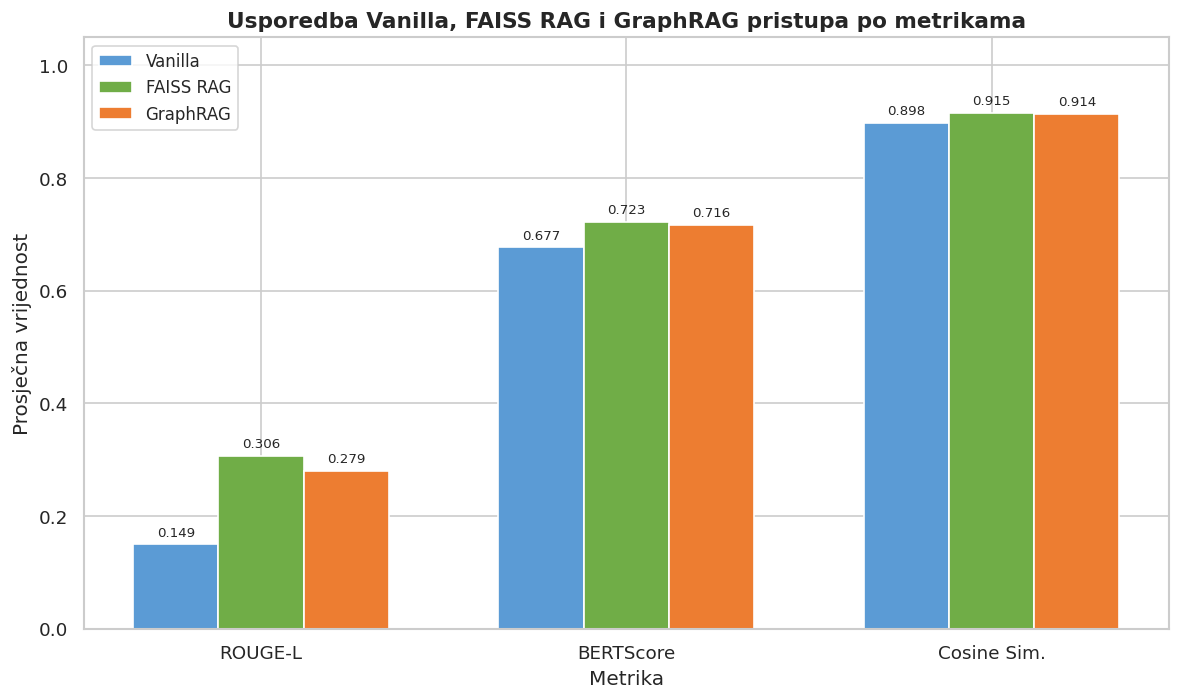

Graf spremljen: /content/drive/My Drive/diplomskiRad/graf_usporedba_pristupa.png


In [12]:
metrika_labeli = ['ROUGE-L', 'BERTScore', 'Cosine Sim.']
metrika_baze_plt = ['rouge_l', 'bertscore', 'cosine']

boje = ['#5B9BD5', '#70AD47', '#ED7D31']  # Vanilla, FAISS RAG, GraphRAG

x = np.arange(len(metrika_labeli))
n_pristupi = len(pristupi)
total_width = 0.7
width = total_width / n_pristupi

fig, ax = plt.subplots(figsize=(10, 6))

for idx, (p, plbl) in enumerate(pristupi):
    offset = (idx - (n_pristupi - 1) / 2) * width
    vals = [df[f'{p}_{b}'].mean() for b in metrika_baze_plt]
    bars = ax.bar(x + offset, vals, width, label=plbl,
                  color=boje[idx], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrika', fontsize=12)
ax.set_ylabel('Prosječna vrijednost', fontsize=12)
ax.set_title('Usporedba Vanilla, FAISS RAG i GraphRAG pristupa po metrikama',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrika_labeli, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)

plt.tight_layout()
save_path = '/content/drive/My Drive/diplomskiRad/graf_usporedba_pristupa.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Graf spremljen: {save_path}')

### Grouped bar chart: Metrike po kategorijama pitanja

Jedan grafikon za svaku metriku, s prikazom po kategorijama pitanja. Svaka kategorija ima bar za svaki pristup.

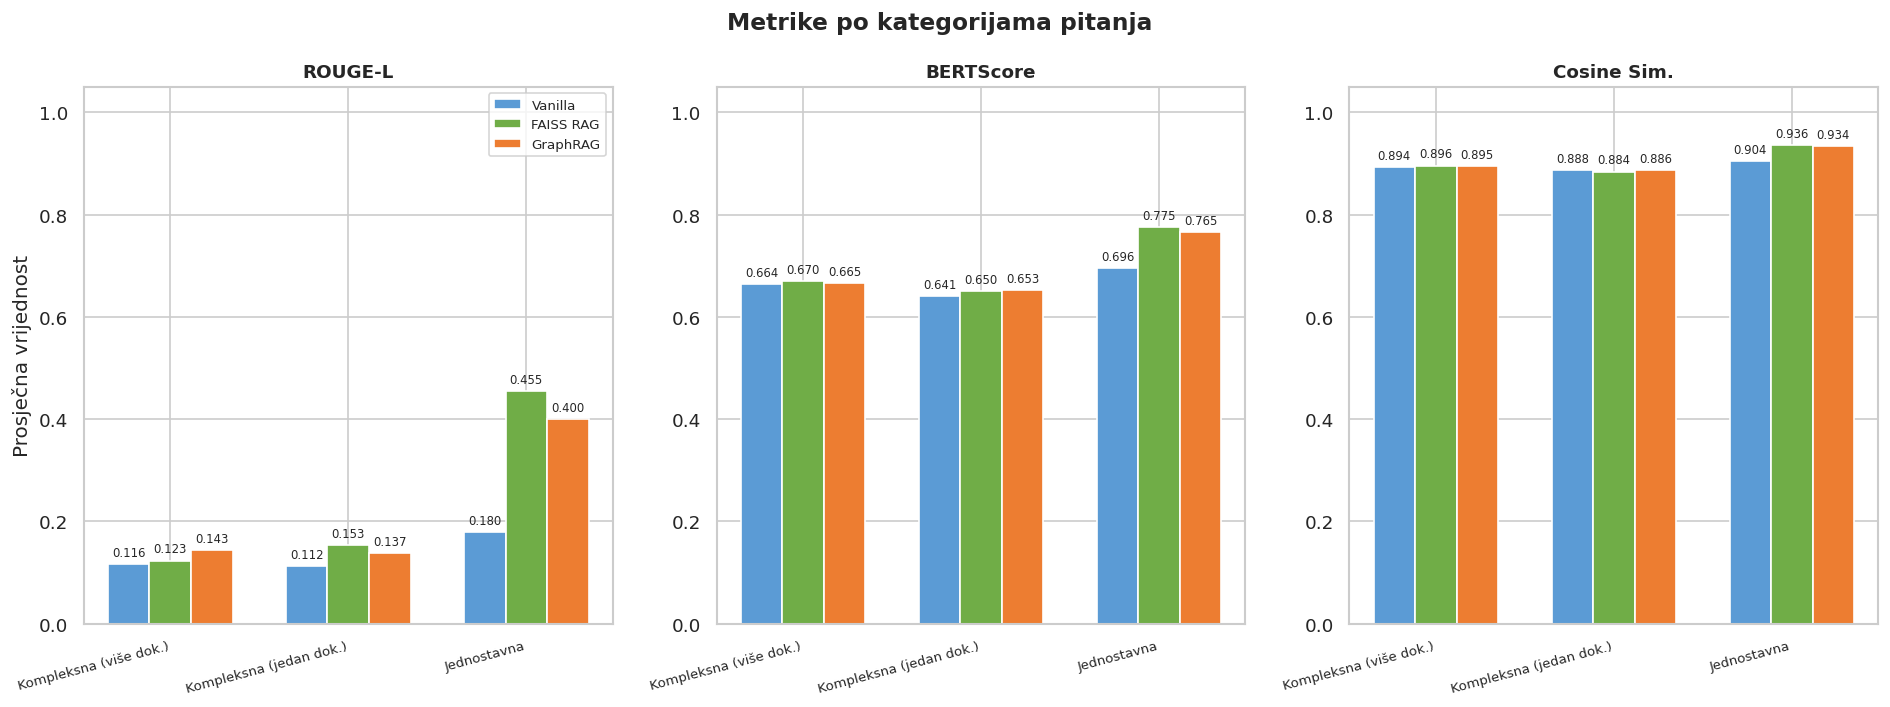

Graf spremljen: /content/drive/My Drive/diplomskiRad/graf_metrike_po_kategorijama.png


In [13]:
kategorije_db = df['kategorija'].unique().tolist()
kategorije_kratko = [naziv_kategorije(k) for k in kategorije_db]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Metrike po kategorijama pitanja', fontsize=14, fontweight='bold')

for idx, (base, naziv) in enumerate(zip(metrika_baze_plt, metrika_labeli)):
    ax = axes[idx]
    x = np.arange(len(kategorije_db))
    n_p = len(pristupi)
    w = 0.7 / n_p

    for j, (p, plbl) in enumerate(pristupi):
        offset = (j - (n_p - 1) / 2) * w
        vals = [df[df['kategorija'] == k][f'{p}_{base}'].mean() for k in kategorije_db]
        bars = ax.bar(x + offset, vals, w, label=plbl,
                      color=boje[j], edgecolor='white')
        for bar in bars:
            if bar.get_height() > 0.02:
                ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
                        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_title(naziv, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(kategorije_kratko, fontsize=8, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    if idx == 0:
        ax.legend(fontsize=8)
    ax.set_ylabel('Prosječna vrijednost' if idx == 0 else '')

plt.tight_layout()
save_path = '/content/drive/My Drive/diplomskiRad/graf_metrike_po_kategorijama.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Graf spremljen: {save_path}')

### Heatmap: Matrica svih metrika po pitanjima

Prikaz svih rezultata evaluacije za svako pitanje. Stupci su grupirani po pristupu (Vanilla, FAISS RAG, GraphRAG), a retci odgovaraju pojedinim pitanjima.

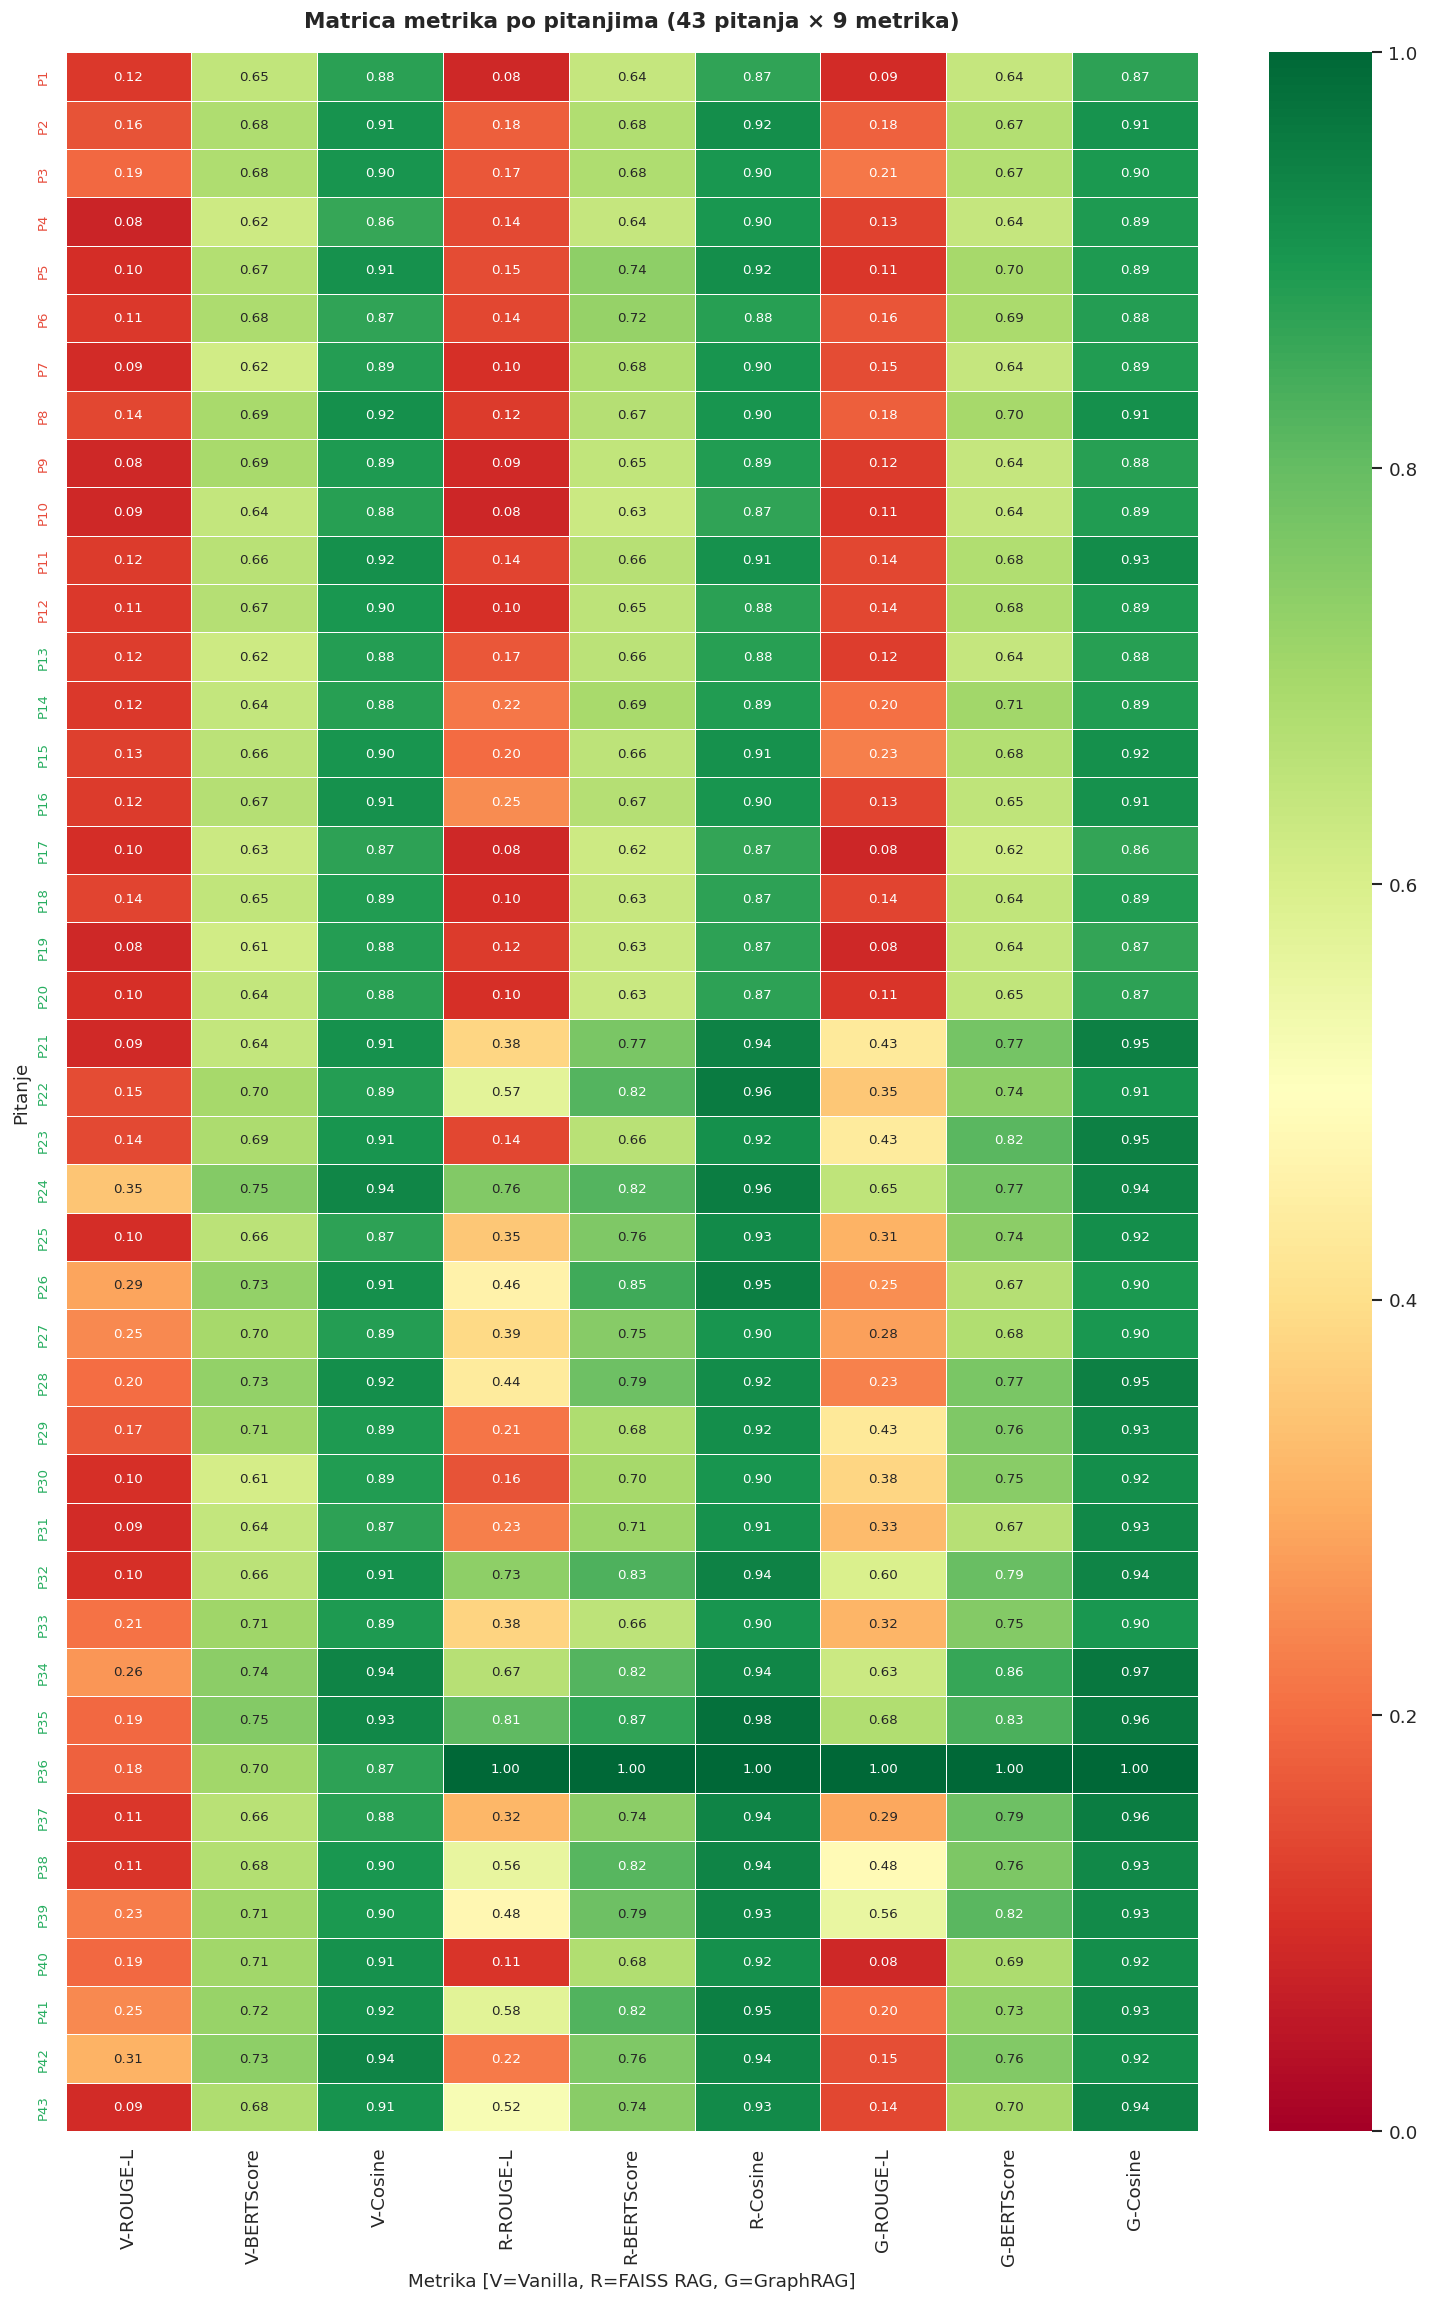

Graf spremljen: /content/drive/My Drive/diplomskiRad/graf_heatmap_metrike.png

Legenda boja (Y os):
  Crvena     = Kompleksna (više dokumenata)
  Narančasta = Kompleksna (jedan dokument)
  Zelena     = Jednostavna pitanja


In [14]:
heatmap_stupci = []
heatmap_nazivi = []
prefiks_mapa = {'vanilla': 'V', 'rag': 'R', 'graph': 'G'}
naziv_mapa   = {'rouge_l': 'ROUGE-L', 'bertscore': 'BERTScore', 'cosine': 'Cosine'}

for p, _ in pristupi:
    for b in metrika_baze_plt:
        col = f'{p}_{b}'
        if col in df.columns:
            heatmap_stupci.append(col)
            heatmap_nazivi.append(f'{prefiks_mapa[p]}-{naziv_mapa[b]}')

heatmap_data = df[heatmap_stupci].copy()
heatmap_data.columns = heatmap_nazivi
heatmap_data.index = [f'P{i+1}' for i in range(len(df))]

fig_h = max(12, len(df) * 0.45)
fig, ax = plt.subplots(figsize=(len(heatmap_stupci) * 1.4, fig_h))

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})

ax.set_title(
    f'Matrica metrika po pitanjima ({len(df)} pitanja × {len(heatmap_stupci)} metrika)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_ylabel('Pitanje', fontsize=11)
ax.set_xlabel('Metrika [V=Vanilla, R=FAISS RAG, G=GraphRAG]', fontsize=11)

boja_kat = []
for kat in df['kategorija']:
    k = kat.lower()
    if 'vise' in k or 'više' in k:
        boja_kat.append('#E74C3C')
    elif 'jedan' in k or 'jedan' in k:
        boja_kat.append('#F39C12')
    else:
        boja_kat.append('#27AE60')

for tick_label, color in zip(ax.get_yticklabels(), boja_kat):
    tick_label.set_color(color)
    tick_label.set_fontsize(8)

plt.tight_layout()
save_path = '/content/drive/My Drive/diplomskiRad/graf_heatmap_metrike.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Graf spremljen: {save_path}')
print('\nLegenda boja (Y os):')
print('  Crvena     = Kompleksna (više dokumenata)')
print('  Narančasta = Kompleksna (jedan dokument)')
print('  Zelena     = Jednostavna pitanja')

## 7. Zaključak

Sažetak rezultata automatskog ocjenjivanja.

In [15]:
sep = '=' * (22 + 12 * len(pristupi))
print(sep)
print('SAŽETAK AUTOMATSKOG OCJENJIVANJA')
print(sep)
print(f'Broj pitanja  : {len(df)}')
print(f'Broj metrika  : 3 (ROUGE-L, BERTScore, Cosine Similarity)')
print(f'Broj kategorija: 3')
print(f'Pristupi      : {", ".join(lbl for _, lbl in pristupi)}')
print()

header = f'{"Metrika":<22}' + ''.join(f'{lbl:>12}' for _, lbl in pristupi)
print(header)
print('-' * (22 + 12 * len(pristupi)))
for base in metrika_baze_plt:
    label = metrike_nazivi_kratki[base]
    vals = [df[f'{p}_{base}'].mean() for p, _ in pristupi]
    row  = f'{label:<22}' + ''.join(f'{v:>12.4f}' for v in vals)
    print(row)

print()
print('Poboljšanje u odnosu na Vanilla:')
print('-' * (22 + 12 * len(pristupi)))
v_means = {b: df[f'vanilla_{b}'].mean() for b in metrika_baze_plt}
for p, plbl in pristupi[1:]:
    bolji = sum(
        1 for b in metrika_baze_plt
        if df[f'{p}_{b}'].mean() > v_means[b]
    )
    print(f'  {plbl}: bolji u {bolji}/{len(metrika_baze_plt)} metrika')
    for base in metrika_baze_plt:
        label = metrike_nazivi_kratki[base]
        diff = df[f'{p}_{base}'].mean() - v_means[base]
        print(f'    {label:<20} {diff:+.4f}')
    print()
print(sep)

SAŽETAK AUTOMATSKOG OCJENJIVANJA
Broj pitanja  : 43
Broj metrika  : 3 (ROUGE-L, BERTScore, Cosine Similarity)
Broj kategorija: 3
Pristupi      : Vanilla, FAISS RAG, GraphRAG

Metrika                    Vanilla   FAISS RAG    GraphRAG
----------------------------------------------------------
ROUGE-L                     0.1494      0.3059      0.2794
BERTScore                   0.6767      0.7226      0.7164
Cosine Sim.                 0.8981      0.9150      0.9142

Poboljšanje u odnosu na Vanilla:
----------------------------------------------------------
  FAISS RAG: bolji u 3/3 metrika
    ROUGE-L              +0.1566
    BERTScore            +0.0459
    Cosine Sim.          +0.0169

  GraphRAG: bolji u 3/3 metrika
    ROUGE-L              +0.1300
    BERTScore            +0.0397
    Cosine Sim.          +0.0161

